# ✅ Great Expectations Config Generator — Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/gx-config-generator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/gx-config-generator/demo.ipynb)

> Setting up data validation is tedious. This tool **auto-profiles any DataFrame** and emits a ready-to-run Great Expectations expectation suite.

**What this notebook covers**
1. The pain: hand-writing validation rules column by column
2. Core logic: profile a column → infer expectations
3. Generate a full suite from sample data
4. Visualize expectation coverage per column
5. Export the suite as GX-compatible JSON
6. Try your own data


## 1. The problem

Every new dataset needs validation rules: *which columns must exist, what's not-null,
what range is sane, which values are allowed, what's a key.* Writing these by hand for
20+ columns is slow and error-prone — so most teams skip it until something breaks in production.

The fix: **profile the data once, infer sensible expectations automatically**, then review.


In [1]:
from __future__ import annotations

import json
from typing import Any, Dict, List

import pandas as pd
from pandas.api import types as ptypes

_UNIQUE_KEY_THRESHOLD = 0.95
_MAX_CATEGORY_VALUES = 20
_NUMERIC_PADDING = 0.10


def _expectation(kind: str, **kwargs: Any) -> Dict[str, Any]:
    return {"expectation_type": kind, "kwargs": kwargs}


def profile_column(col: str, s: pd.Series, row_count: int) -> List[Dict[str, Any]]:
    """Infer the list of expectations for one column."""
    exps: List[Dict[str, Any]] = [_expectation("expect_column_to_exist", column=col)]

    non_null = int(s.notna().sum())
    null_ratio = 1 - (non_null / row_count) if row_count else 0.0
    if null_ratio == 0:
        exps.append(_expectation("expect_column_values_to_not_be_null", column=col))
    else:
        exps.append(_expectation("expect_column_values_to_not_be_null",
                                 column=col, mostly=round(1 - null_ratio, 3)))

    if non_null and s.nunique(dropna=True) / non_null >= _UNIQUE_KEY_THRESHOLD:
        exps.append(_expectation("expect_column_values_to_be_unique", column=col))

    if ptypes.is_numeric_dtype(s) and not ptypes.is_bool_dtype(s):
        lo, hi = float(s.min()), float(s.max())
        span = hi - lo
        pad = abs(span) * _NUMERIC_PADDING if span else abs(hi) * _NUMERIC_PADDING
        exps.append(_expectation("expect_column_values_to_be_between", column=col,
                                 min_value=round(lo - pad, 4), max_value=round(hi + pad, 4)))
        dtype = "int" if ptypes.is_integer_dtype(s) else "float"
        exps.append(_expectation("expect_column_values_to_be_of_type", column=col, type_=dtype))
    else:
        distinct = s.dropna().unique().tolist()
        if 0 < len(distinct) <= _MAX_CATEGORY_VALUES:
            exps.append(_expectation("expect_column_values_to_be_in_set", column=col,
                                     value_set=sorted(map(str, distinct))))
    return exps


print("Core profiling logic defined.")

Core profiling logic defined.


## 2. Assemble a full suite

`generate_suite` adds two table-level checks (row count, column set) then profiles every column.


In [2]:
def generate_suite(df: pd.DataFrame, suite_name: str = "auto_generated_suite") -> Dict[str, Any]:
    row_count = len(df)
    expectations: List[Dict[str, Any]] = [
        _expectation("expect_table_row_count_to_be_between", min_value=1, max_value=row_count * 10),
        _expectation("expect_table_columns_to_match_set", column_set=list(df.columns)),
    ]
    for col in df.columns:
        expectations.extend(profile_column(col, df[col], row_count))
    return {
        "expectation_suite_name": suite_name,
        "ge_cloud_id": None,
        "meta": {"generated_by": "gx-config-generator", "source_rows": row_count},
        "expectations": expectations,
    }


print("Suite generator ready.")

Suite generator ready.


## 3. Sample data → suite

A small e-commerce orders table. Note: `discount_pct` has nulls, `order_id` is a key,
`status`/`region` are categoricals.


In [3]:
df = pd.DataFrame({
    "order_id": range(1001, 1011),
    "customer_email": [f"user{i}@example.com" for i in range(10)],
    "amount": [12.5, 99.0, 5.25, 250.0, 18.75, 42.0, 7.5, 310.0, 21.0, 64.5],
    "status": ["paid", "paid", "refunded", "paid", "pending",
               "paid", "refunded", "paid", "pending", "paid"],
    "region": ["NA", "EU", "NA", "APAC", "EU", "NA", "EU", "APAC", "NA", "EU"],
    "discount_pct": [0, 10, 0, 5, None, 0, 15, 0, None, 5],
})
df

,order_id,customer_email,amount,status,region,discount_pct
0,1001,user0@example.com,12.50,paid,NA,0.0
1,1002,user1@example.com,99.00,paid,EU,10.0
2,1003,user2@example.com,5.25,refunded,NA,0.0
3,1004,user3@example.com,250.00,paid,APAC,5.0
4,1005,user4@example.com,18.75,pending,EU,NaN
5,1006,user5@example.com,42.00,paid,NA,0.0
6,1007,user6@example.com,7.50,refunded,EU,15.0
7,1008,user7@example.com,310.00,paid,APAC,0.0
8,1009,user8@example.com,21.00,pending,NA,NaN
9,1010,user9@example.com,64.50,paid,EU,5.0


In [4]:
suite = generate_suite(df, "orders_suite")
print(f"Generated {len(suite['expectations'])} expectations across {len(df.columns)} columns.\n")
for exp in suite["expectations"][:8]:
    col = exp["kwargs"].get("column", "<table>")
    print(f"  [{col:>14}]  {exp['expectation_type']}")

Generated 26 expectations across 6 columns.

  [       <table>]  expect_table_row_count_to_be_between
  [       <table>]  expect_table_columns_to_match_set
  [      order_id]  expect_column_to_exist
  [      order_id]  expect_column_values_to_not_be_null
  [      order_id]  expect_column_values_to_be_unique
  [      order_id]  expect_column_values_to_be_between
  [      order_id]  expect_column_values_to_be_of_type
  [customer_email]  expect_column_to_exist


## 4. Coverage chart

How many expectations each column got — a quick read on where validation is concentrated.


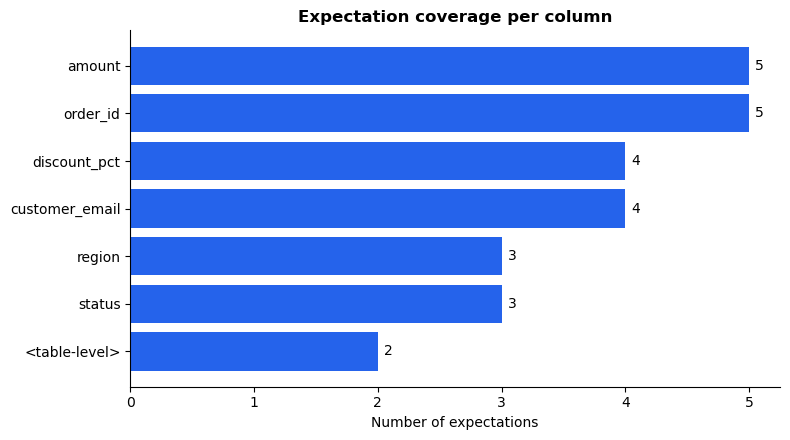

In [5]:
import matplotlib.pyplot as plt

counts: Dict[str, int] = {}
for exp in suite["expectations"]:
    c = exp["kwargs"].get("column", "<table-level>")
    counts[c] = counts.get(c, 0) + 1

cols = sorted(counts, key=counts.get)
vals = [counts[c] for c in cols]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(cols, vals, color="#2563eb")
ax.set_xlabel("Number of expectations")
ax.set_title("Expectation coverage per column", fontweight="bold")
for i, v in enumerate(vals):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("coverage.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Export as GX-compatible JSON

Drop this into `great_expectations/expectations/<name>.json` and run a checkpoint.


In [6]:
print(json.dumps(suite, indent=2)[:900])

{
  "expectation_suite_name": "orders_suite",
  "ge_cloud_id": null,
  "meta": {
    "generated_by": "gx-config-generator",
    "source_rows": 10
  },
  "expectations": [
    {
      "expectation_type": "expect_table_row_count_to_be_between",
      "kwargs": {
        "min_value": 1,
        "max_value": 100
      }
    },
    {
      "expectation_type": "expect_table_columns_to_match_set",
      "kwargs": {
        "column_set": [
          "order_id",
          "customer_email",
          "amount",
          "status",
          "region",
          "discount_pct"
        ]
      }
    },
    {
      "expectation_type": "expect_column_to_exist",
      "kwargs": {
        "column": "order_id"
      }
    },
    {
      "expectation_type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "order_id"
      }
    },
    {
      "expectation_type": "expect_column_valu


## Summary

| Step | Output |
|------|--------|
| Profile each column | not-null, unique-key, range, type, allowed-set rules |
| Table-level checks | row count + column set |
| Export | GX `ExpectationSuite` JSON, ready for a checkpoint |

The auto-generated bounds are a **starting point** — review and tighten before trusting them in CI.


## 🔧 Try your own data

Uncomment and point at your own CSV:


In [7]:
# my_df = pd.read_csv("your_data.csv")
# my_suite = generate_suite(my_df, "my_suite")
# print(f"{len(my_suite['expectations'])} expectations generated")
# with open("my_suite.json", "w") as f:
#     json.dump(my_suite, f, indent=2)
# print("Saved my_suite.json")

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — a 60-project FDE portfolio.

**Streamlit version:** `pip install -r requirements.txt && streamlit run app.py` — upload a CSV and download the suite from the browser.
